## General imports

In [1]:
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2
from qiskit.visualization import plot_histogram,plot_distribution
import matplotlib.pyplot as plt

In [2]:
import os, sys

# We are in src/ssp → parent is src, which contains the "ssp" package
PARENT_OF_PACKAGE = os.path.abspath("..")
if PARENT_OF_PACKAGE not in sys.path:
    sys.path.insert(0, PARENT_OF_PACKAGE)

from ssp import SubsetSumInstance
from ssp.solvers import DGSSPSolver, DGConfig, DPSSPSolver, DPConfig
from ssp.backends import (
    BackendSelectionConfig,
    build_service,
    list_real_backends,
    build_all_backends,
    evaluate_backends_for_circuit,
    select_best_backends,
)
from ssp.transpilation import find_best_seed 
from ssp.mitigation import ZNESamplingConfig, dgssp_zne_mitigated_distribution
from ssp.mitigation.zne import _run_folded_circuit_sampling

from ssp.execution import (
    execute_ideal,
    execute_noisy,
    execute_optimized_mitigated,
)

## solvers example

In [3]:
# --- Classical DP solver test ---

# Define a small SSP instance
instance = SubsetSumInstance(items=[1,2,3], target=5, name="toy")

# Create the DP solver (dynamic programming)
dp_cfg = DPConfig(enumerate_all=True)
dp_solver = DPSSPSolver(dp_cfg)

dp_result = dp_solver.solve(instance)

print("Instance:", instance)
print("Number of items:", instance.n_items)
print("Target:", instance.target)

print("\nDP success:", dp_result.success)
print("Optimal value:", dp_result.optimal_value)
print("Best solution:", dp_result.best_solution)

print("\nAll solutions:")
for sol in dp_result.all_solutions:
    print("  indices =", sol.indices,
          "subset =", sol.subset,
          "total =", sol.total,
          "is_exact =", sol.is_exact)


Instance: SubsetSumInstance(items=[1, 2, 3], target=5, name='toy', metadata={})
Number of items: 3
Target: 5

DP success: True
Optimal value: 5
Best solution: SSPSolution(indices=[1, 2], subset=[2, 3], total=5, is_exact=True)

All solutions:
  indices = [1, 2] subset = [2, 3] total = 5 is_exact = True


     ┌───┐ ░ ┌─────────────┐ ░ ┌─────────────────┐ ░ ┌─┐      
i_0: ┤ H ├─░─┤0            ├─░─┤0                ├─░─┤M├──────
     ├───┤ ░ │             │ ░ │                 │ ░ └╥┘┌─┐   
i_1: ┤ H ├─░─┤1            ├─░─┤1 GroverDiffuser ├─░──╫─┤M├───
     ├───┤ ░ │             │ ░ │                 │ ░  ║ └╥┘┌─┐
i_2: ┤ H ├─░─┤2            ├─░─┤2                ├─░──╫──╫─┤M├
     └───┘ ░ │  DGSSP_Step │ ░ └─────────────────┘ ░  ║  ║ └╥┘
s_0: ──────░─┤3            ├─░─────────────────────░──╫──╫──╫─
           ░ │             │ ░                     ░  ║  ║  ║ 
s_1: ──────░─┤4            ├─░─────────────────────░──╫──╫──╫─
           ░ │             │ ░                     ░  ║  ║  ║ 
s_2: ──────░─┤5            ├─░─────────────────────░──╫──╫──╫─
           ░ └─────────────┘ ░                     ░  ║  ║  ║ 
c: 3/═════════════════════════════════════════════════╩══╩══╩═
                                                      0  1  2 


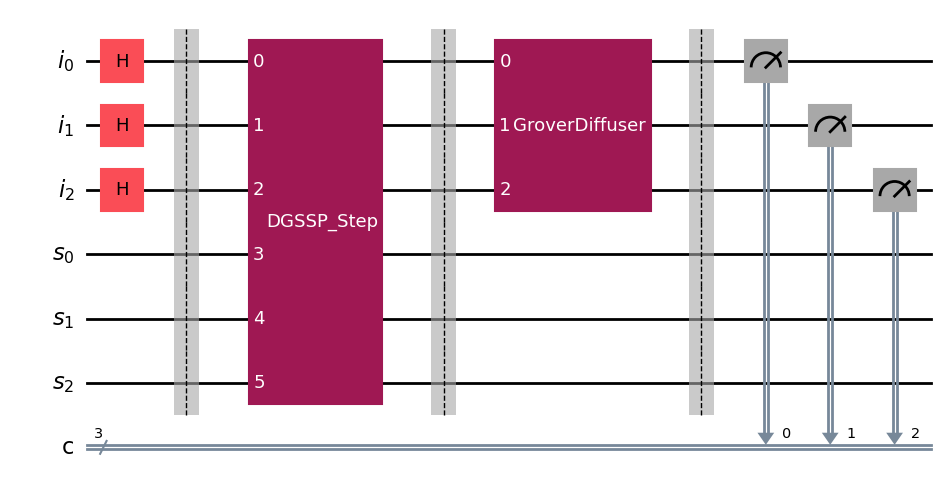

DGConfig(assembly_type='FullQFT', iterations=1)

In [4]:
# --- DG circuit construction ---

dg_cfg = DGConfig(assembly_type="FullQFT", iterations=1)
dg_solver = DGSSPSolver(dg_cfg)

qc = dg_solver.build_circuit(instance)

print(qc)
display(qc.draw("mpl"))
dg_cfg

In [5]:
# --- Helper: run a circuit on a backend and get counts ---

def run_on_backend(backend, circuit, shots: int = 4096):
    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=0,
        seed_transpiler=1234,
    )
    tqc = pm.run(circuit)

    sampler = SamplerV2(mode=backend)
    job = sampler.run([tqc], shots=shots)
    pub_result = job.result()[0]
    counts = pub_result.join_data().get_counts()
    return tqc, counts

Transpiled depth: 38
Counts: {'110': 3207, '011': 140, '100': 118, '010': 123, '111': 115, '101': 137, '000': 127, '001': 129}


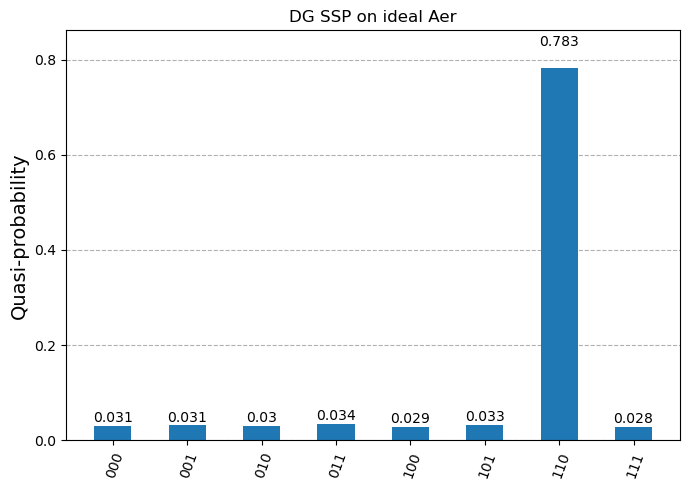

In [6]:
# --- Run DG circuit on ideal Aer simulator ---

backend = AerSimulator()
tqc, counts = run_on_backend(backend, qc, shots=4096)

print("Transpiled depth:", tqc.depth())
print("Counts:", counts)

plot_distribution(counts, title="DG SSP on ideal Aer")
#plt.show()

In [7]:
# Decode measurement bitstrings into subsets for this instance

def bitstring_to_indices(bitstring: str) -> list[int]:
    """Convert Qiskit bitstring (MSB→LSB) to list of selected indices."""
    # Qiskit counts bitstrings are msb→lsb (q_{n-1} ... q_0)
    # Our index 0 is the *least* significant bit, so reverse first.
    bits_lsb_first = bitstring[::-1]
    return [i for i, b in enumerate(bits_lsb_first) if b == "1"]


def decode_counts_to_solutions(counts, instance: SubsetSumInstance):
    total_shots = sum(counts.values())
    solutions = []

    for bitstring, c in sorted(counts.items(), key=lambda kv: kv[1], reverse=True):
        indices = bitstring_to_indices(bitstring)
        sol = instance.subset_from_indices(indices)
        if sol.is_exact:
            prob = c / total_shots
            solutions.append((bitstring, sol, prob))
    return solutions

In [8]:
solutions = decode_counts_to_solutions(counts, instance)

print("\nDG solver: solutions found in measurement results:")
for bitstring, sol, prob in solutions:
    print(f"  state {bitstring} -> subset {sol.subset} (sum={sol.total}), p≈{prob:.3f}")



DG solver: solutions found in measurement results:
  state 110 -> subset [2, 3] (sum=5), p≈0.783


## backends.py module example

In [9]:
# Configure where your IBM account JSON is and a min qubit threshold if you want
cfg = BackendSelectionConfig(
    min_qubits=5,   # for example, require at least 5 qubits; or use None for no filter
    seed_simulator=None,
)

# Build the IBM Runtime service
service = build_service(cfg)

# Get *usable* real backends: non-simulators, enough qubits, operational, not in maintenance
real_backends = list_real_backends(service, min_qubits=cfg.min_qubits)

print(f"Found {len(real_backends)} usable real backends:\n")

for backend in real_backends:
    status = backend.status()
    name_attr = getattr(backend, "name", None)
    backend_name = name_attr() if callable(name_attr) else (name_attr or str(backend))

    print(
        f"- {backend_name}: "
        f"{status.backend_version}, "
        f"operational={status.operational}, "
        f"pending_jobs={status.pending_jobs}, "
        f"status_msg='{status.status_msg}'"
    )

Found 3 usable real backends:

- ibm_fez: , operational=True, pending_jobs=5, status_msg='active'
- ibm_torino: , operational=True, pending_jobs=0, status_msg='active'
- ibm_marrakesh: , operational=True, pending_jobs=20938, status_msg='active'


In [10]:
print("All backends visible to this account:")
for b in service.backends():
    s = b.status()
    n = b.name if not callable(getattr(b, "name", None)) else b.name()
    print(
        f"- {n}: simulator={b.configuration().simulator}, "
        f"num_qubits={b.configuration().num_qubits}, "
        f"operational={s.operational}, status_msg='{s.status_msg}'"
    )

All backends visible to this account:
- ibm_fez: simulator=False, num_qubits=156, operational=True, status_msg='active'
- ibm_torino: simulator=False, num_qubits=133, operational=True, status_msg='active'
- ibm_marrakesh: simulator=False, num_qubits=156, operational=True, status_msg='active'


## best_backends module example

In [11]:
# 1) Build backends
cfg = BackendSelectionConfig(min_qubits=3, seed_simulator=1234)
bk = build_all_backends(cfg)
#real_backends = bk["real_backends"]
real_backends = []
fake_backends = bk["fake_backends"]


In [12]:
fake_backends

[AerSimulator('aer_simulator_from(ibm_fez)'
              noise_model=<NoiseModel on ['reset', 'x', 'sx', 'measure', 'cz', 'id']>),
 AerSimulator('aer_simulator_from(ibm_torino)'
              noise_model=<NoiseModel on ['reset', 'x', 'sx', 'measure', 'cz', 'id']>),
 AerSimulator('aer_simulator_from(ibm_marrakesh)'
              noise_model=<NoiseModel on ['reset', 'x', 'sx', 'measure', 'cz', 'id']>)]

In [13]:
real_backends

[]

In [14]:
perf = evaluate_backends_for_circuit(
    instance,
    qc,
    real_backends=real_backends,
    fake_backends=fake_backends,
    shots=2**15,
    noise_seed=1234,
)

In [15]:
best = select_best_backends(perf["real"], perf["fake"])

best_real_error = best["best_real_by_error"]
best_real_prob = best["best_real_by_probability"]
best_fake_error = best["best_fake_by_error"]
best_fake_prob = best["best_fake_by_probability"]

In [16]:
best

{'best_real_by_error': None,
 'best_fake_by_error': BackendPerformance(backend=AerSimulator('aer_simulator_from(ibm_marrakesh)'
              noise_model=<NoiseModel on ['reset', 'x', 'sx', 'measure', 'cz', 'id']>), backend_name='aer_simulator_from(ibm_marrakesh)', is_real=False, transpiled_circuit=<qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x0000013729DAD7C0>, errors=BackendErrorMetrics(total_error=0.5679560234078299, two_qubit_error=0.45392796354062503, single_qubit_error=0.09803684892970492, readout_error=0.0159912109375, single_qubit_gate_count=865, two_qubit_gate_count=189), counts={'001': 2394, '111': 2742, '000': 2304, '011': 2329, '110': 15428, '100': 2609, '101': 2602, '010': 2360}, solution_probability=0.4708251953125),
 'best_real_by_probability': None,
 'best_fake_by_probability': BackendPerformance(backend=AerSimulator('aer_simulator_from(ibm_marrakesh)'
              noise_model=<NoiseModel on ['reset', 'x', 'sx', 'measure', 'cz', 'id']>), backend_name='aer_s

In [17]:
best_real_error

In [18]:
best_real_prob

In [19]:
best_fake_error.backend_name

'aer_simulator_from(ibm_marrakesh)'

In [20]:
best_fake_prob

BackendPerformance(backend=AerSimulator('aer_simulator_from(ibm_marrakesh)'
             noise_model=<NoiseModel on ['reset', 'x', 'sx', 'measure', 'cz', 'id']>), backend_name='aer_simulator_from(ibm_marrakesh)', is_real=False, transpiled_circuit=<qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x0000013729DAD7C0>, errors=BackendErrorMetrics(total_error=0.5679560234078299, two_qubit_error=0.45392796354062503, single_qubit_error=0.09803684892970492, readout_error=0.0159912109375, single_qubit_gate_count=865, two_qubit_gate_count=189), counts={'001': 2394, '111': 2742, '000': 2304, '011': 2329, '110': 15428, '100': 2609, '101': 2602, '010': 2360}, solution_probability=0.4708251953125)

# Transpilation module

## Finding the optimal layout

In [21]:
# 3) Find best SABRE layout / seed for this backend
fake_backend= bk["fake_backends"][1]

best = find_best_seed(qc, fake_backend, seed_min=0, seed_max=128)

print("Best seed:", best.best_seed)
print("Total 2q error:", best.total_two_qubit_error)
print("2q gate count:", best.two_qubit_gate_count)

best_circuit = best.circuit  # use this to actually run DG-SSP

Best seed: 43
Total 2q error: 0.20809915479941954
2q gate count: 113


# Quantum Error Mitigation: ZNE

# Full execution options

In [3]:
import os, sys
from pprint import pprint

# We are in src/ssp → parent is src, which contains the "ssp" package
PARENT_OF_PACKAGE = os.path.abspath("..")
if PARENT_OF_PACKAGE not in sys.path:
    sys.path.insert(0, PARENT_OF_PACKAGE)

import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram, plot_distribution

from ssp import (
    SubsetSumInstance,
    DGConfig,
    DGSSPSolver,
    BackendSelectionConfig,
    build_all_backends,
    ZNESamplingConfig,
)
from ssp.execution import (
    execute_ideal,
    execute_noisy,
    execute_optimized_mitigated,
)


     ┌───┐ ░ ┌─────────────┐ ░ ┌─────────────────┐ ░ ┌─┐      
i_0: ┤ H ├─░─┤0            ├─░─┤0                ├─░─┤M├──────
     ├───┤ ░ │             │ ░ │                 │ ░ └╥┘┌─┐   
i_1: ┤ H ├─░─┤1            ├─░─┤1 GroverDiffuser ├─░──╫─┤M├───
     ├───┤ ░ │             │ ░ │                 │ ░  ║ └╥┘┌─┐
i_2: ┤ H ├─░─┤2            ├─░─┤2                ├─░──╫──╫─┤M├
     └───┘ ░ │  DGSSP_Step │ ░ └─────────────────┘ ░  ║  ║ └╥┘
s_0: ──────░─┤3            ├─░─────────────────────░──╫──╫──╫─
           ░ │             │ ░                     ░  ║  ║  ║ 
s_1: ──────░─┤4            ├─░─────────────────────░──╫──╫──╫─
           ░ │             │ ░                     ░  ║  ║  ║ 
s_2: ──────░─┤5            ├─░─────────────────────░──╫──╫──╫─
           ░ └─────────────┘ ░                     ░  ║  ║  ║ 
c: 3/═════════════════════════════════════════════════╩══╩══╩═
                                                      0  1  2 


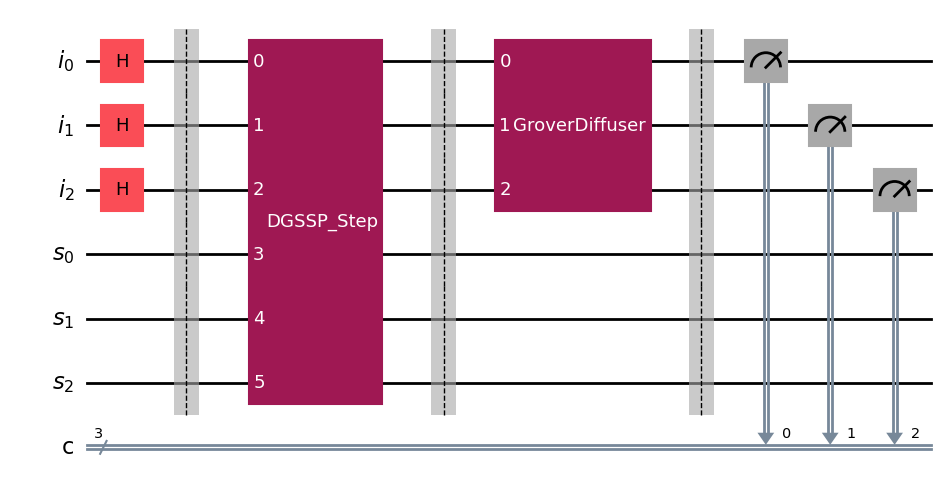

DGConfig(assembly_type='FullQFT', iterations=1)

In [4]:
# 1) Define a DG-SSP instance and build the circuit

instance = SubsetSumInstance(items=[1,2,3], target=5, name="toy")

dg_cfg = DGConfig(assembly_type="FullQFT", iterations=1)
dg_solver = DGSSPSolver(dg_cfg)

qc = dg_solver.build_circuit(instance)

print(qc)
display(qc.draw("mpl"))
dg_cfg

In [5]:
# 2) Helper utilities: counts→probs and solution detection

def counts_to_probs(counts):
    total = sum(counts.values())
    if total == 0:
        return {b: 0.0 for b in counts}
    return {b: c / total for b, c in counts.items()}

def bit_is_solution(bitstring: str, items, target: int) -> bool:
    """Interpret bitstring as subset of `items` (LSB-first) and check sum == target."""
    # Qiskit bitstrings: leftmost bit is most significant
    bits_lsb_first = list(reversed(bitstring))
    subset = [items[i] for i, bit in enumerate(bits_lsb_first) if bit == "1"]
    return sum(subset) == target

def solution_bitstrings_from_dist(dist, items, target):
    """Return the list of bitstrings that encode valid SSP solutions, seen in dist."""
    return sorted(
        [b for b in dist.keys() if bit_is_solution(b, items, target)]
    )


In [6]:
#3) Build backends bundle (ideal, fake, real)

# Use at least as many qubits as the DG circuit uses
min_qubits = qc.num_qubits

bk_cfg = BackendSelectionConfig(
    min_qubits=min_qubits,
    seed_simulator=1234,
    real=False,
)

backends_bundle = build_all_backends(bk_cfg)

ideal_backend = backends_bundle["ideal"]
fake_backends = backends_bundle["fake_backends"]
real_backends = backends_bundle["real_backends"]

print("Ideal backend:", ideal_backend)
print("Number of fake backends:", len(fake_backends))
print("Number of real backends:", len(real_backends))

Ideal backend: AerSimulator('aer_simulator')
Number of fake backends: 3
Number of real backends: 0


In [7]:
# 4) Run IDEAL executor

ideal_res = execute_ideal(
    qc,
    shots=4096,
    seed_simulator=1234,
    optimization_level=0,
)

p_ideal = counts_to_probs(ideal_res.counts)
print("Ideal counts:")
pprint(ideal_res.counts)


Ideal counts:
{'000': 113,
 '001': 131,
 '010': 127,
 '011': 125,
 '100': 134,
 '101': 133,
 '110': 3208,
 '111': 125}


In [8]:
# 5) Run NOISY executor on first fake backend

if not fake_backends:
    raise RuntimeError("No fake backends available; check your IBM account / config.")

noisy_backend = fake_backends[2]

noisy_res = execute_noisy(
    qc,
    noisy_backend,
    shots=4096,
    seed_transpiler=0,
    seed_simulator=1234,
    optimization_level=0,
)

p_noisy = counts_to_probs(noisy_res.counts)
print("Noisy counts (fake backend):")
pprint(noisy_res.counts)


Noisy counts (fake backend):
{'000': 282,
 '001': 284,
 '010': 313,
 '011': 295,
 '100': 338,
 '101': 281,
 '110': 1998,
 '111': 305}


In [9]:
# 6) Run OPTIMIZED / MITIGATED executor (best backend + SABRE + ZNE)

zne_cfg = ZNESamplingConfig(
    scales=[1, 3, 5],
    shots_per_scale=2**10,
    method="linear",
    clip=True,
    renormalize=True,
    seed_min=0,
    seed_max=500,
    optimization_level=3,
    layout_method="sabre",
    seed_simulator=1234,
)

opt_results = execute_optimized_mitigated(
    qc,
    backends_bundle,
    zne_cfg,
    shots_unmitigated=2**15,
)

best_fake_res = opt_results["best_fake"]
best_real_res = opt_results["best_real"]

print("\nOptimized/mitigated results:")
print("Best fake backend:", None if best_fake_res is None else best_fake_res.backend_name)
print("Best real backend:", None if best_real_res is None else best_real_res.backend_name)



Optimized/mitigated results:
Best fake backend: aer_simulator_from(ibm_marrakesh)
Best real backend: None


In [10]:
# 7) Extract the ZNE-mitigated distribution (pick best_fake if available)

p_mit_f = best_fake_res.mitigated_distribution
backend_label_mit_f = f"ZNE on {best_fake_res.backend_name}"

#p_mit_r = best_real_res.mitigated_distribution
#backend_label_mit_r = f"ZNE on {best_real_res.backend_name}"

In [11]:
# 8) Identify solution bitstrings and print their probabilities under each executor

items = instance.items
target = instance.target

solutions = sorted(set(
    solution_bitstrings_from_dist(p_ideal, items, target)
    + solution_bitstrings_from_dist(p_noisy, items, target)
    + solution_bitstrings_from_dist(p_mit_f, items, target)
))

print("\nSolution bitstrings (found in any distribution):", solutions)

def print_solution_probs(label, dist):
    print(f"\n{label}:")
    for s in solutions:
        print(f"  {s}: {dist.get(s, 0.0):.6f}")

print_solution_probs("Ideal", p_ideal)
print_solution_probs("Noisy (fake backend)", p_noisy)
print_solution_probs(backend_label_mit_f, p_mit_f)
#print_solution_probs(backend_label_mit_r, p_mit_r)



Solution bitstrings (found in any distribution): ['110']

Ideal:
  110: 0.783203

Noisy (fake backend):
  110: 0.487793

ZNE on aer_simulator_from(ibm_marrakesh):
  110: 0.611328


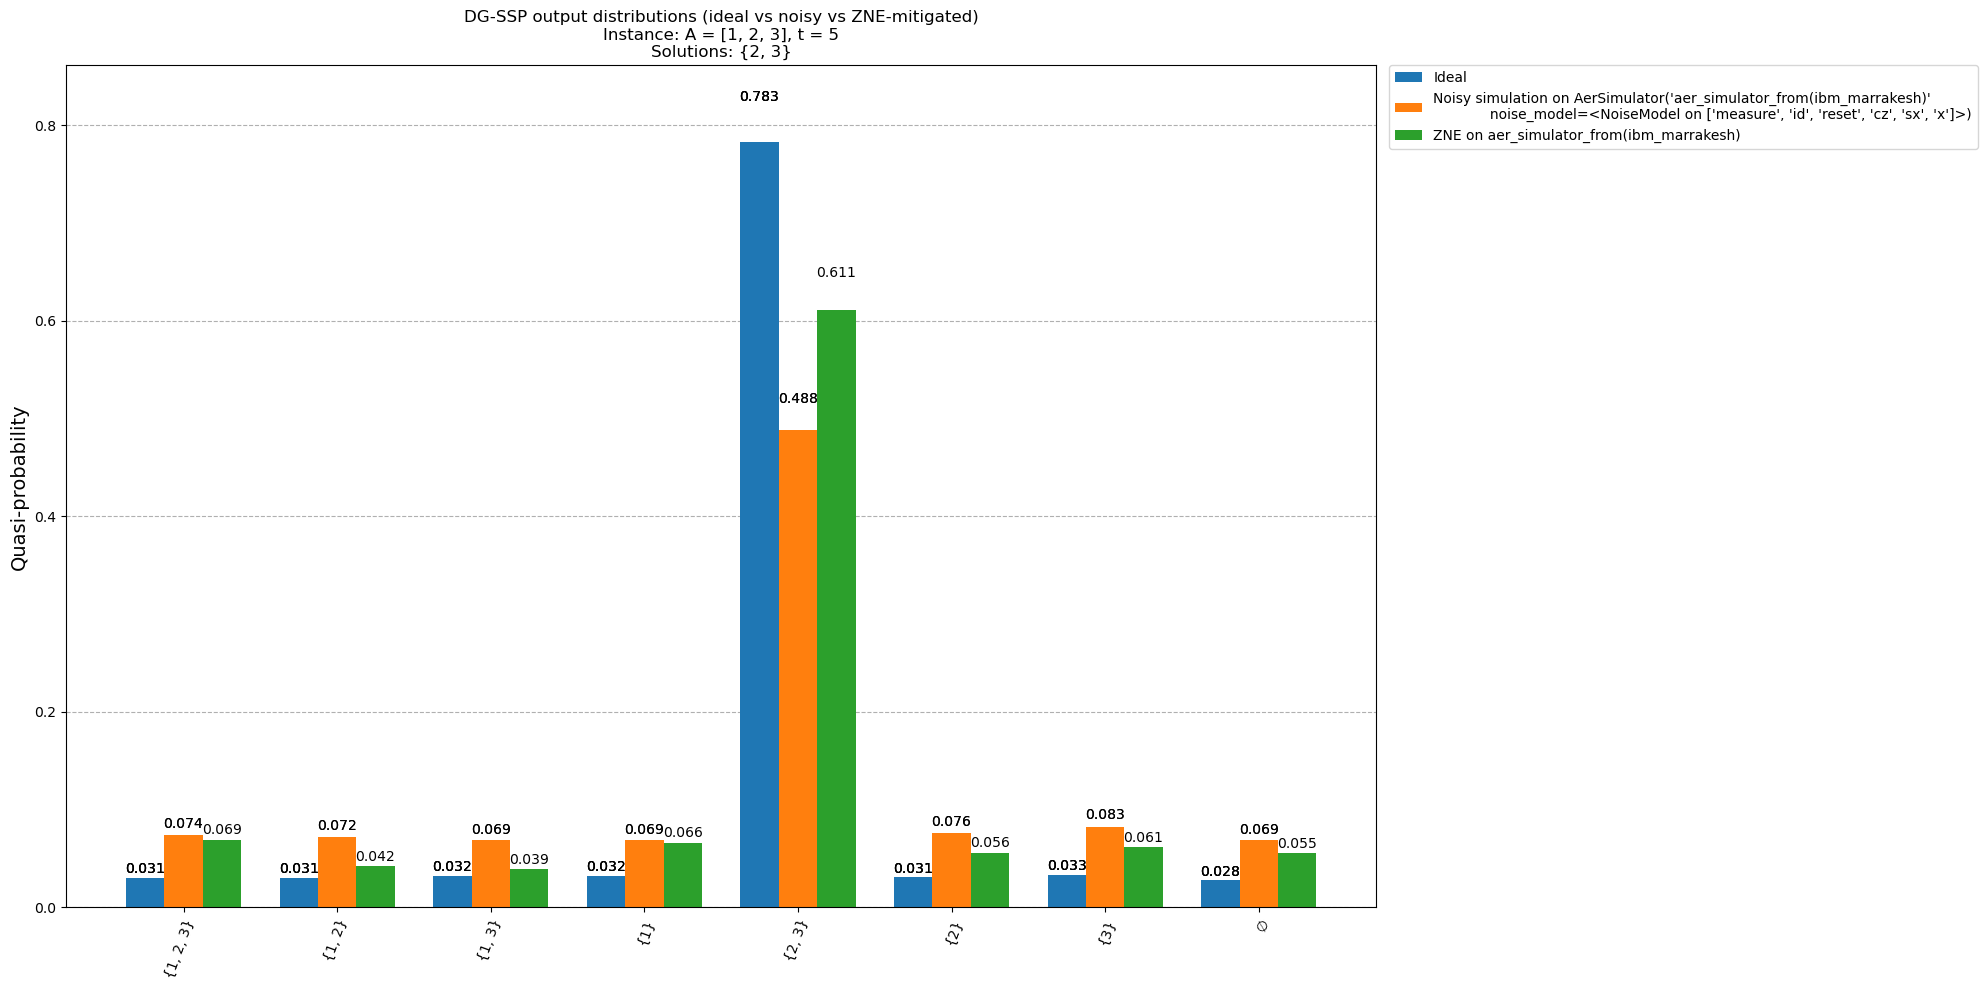

In [12]:
# 9) Plot distributions for visual comparison (x-axis = subsets instead of bitstrings)

from qiskit.visualization import plot_distribution

# --- Helper: map bitstring -> subset label {a,b,c} ---
def bitstring_to_subset_label(bitstring: str, items) -> str:
    # Qiskit bitstrings: leftmost bit is most significant
    bits_lsb_first = list(reversed(bitstring))
    subset = [items[i] for i, bit in enumerate(bits_lsb_first) if bit == "1"]
    if not subset:
        return "∅"
    return "{" + ", ".join(str(x) for x in subset) + "}"

# 1) All bitstrings that appear in at least one distribution
all_bits = sorted(set(p_ideal.keys()) | set(p_noisy.keys()) | set(p_mit_f.keys()))
#all_bits = sorted(set(p_ideal.keys()) | set(p_noisy.keys()) | set(p_mit_f.keys())| set(p_mit_r.keys()))

# 2) Build mapping bitstring -> subset label
bit_to_subset = {b: bitstring_to_subset_label(b, items) for b in all_bits}

# 3) Convert bitstring distributions -> subset distributions (aggregate if needed)
def bits_to_subsets_dist(p_bits: dict[str, float]) -> dict[str, float]:
    subset_dist: dict[str, float] = {}
    for b, prob in p_bits.items():
        label = bit_to_subset[b]
        subset_dist[label] = subset_dist.get(label, 0.0) + prob
    return subset_dist

p_ideal_sub = bits_to_subsets_dist(p_ideal)
p_noisy_sub = bits_to_subsets_dist(p_noisy)
p_mit_sub_f   = bits_to_subsets_dist(p_mit_f)
#p_mit_sub_r   = bits_to_subsets_dist(p_mit_r)

# 4) Unified x-axis: all subset labels that appear anywhere
all_subsets = sorted(set(p_ideal_sub.keys()) | set(p_noisy_sub.keys()) | set(p_mit_sub_f.keys()))
#all_subsets = sorted(set(p_ideal_sub.keys()) | set(p_noisy_sub.keys()) | set(p_mit_sub_f.keys())| set(p_mit_sub_r.keys()))

def align_dist(dist, keys):
    return {k: dist.get(k, 0.0) for k in keys}

p_ideal_aligned = align_dist(p_ideal_sub, all_subsets)
p_noisy_aligned = align_dist(p_noisy_sub, all_subsets)
p_mit_aligned_f   = align_dist(p_mit_sub_f, all_subsets)
#p_mit_aligned_r   = align_dist(p_mit_sub_r, all_subsets)

# 5) Convert solution bitstrings -> subset labels for display
solution_labels = sorted({bit_to_subset[b] for b in solutions})

instance_str = f"A = {items}, t = {target}"
solutions_str = ", ".join(solution_labels) if solution_labels else "None"

title = (
    "DG-SSP output distributions (ideal vs noisy vs ZNE-mitigated)\n"
    f"Instance: {instance_str}\n"
    f"Solutions: {solutions_str}"
)
noisy_label = f"Noisy simulation on {noisy_backend}"
plot_distribution(
    [p_ideal_aligned, p_noisy_aligned, p_mit_aligned_f],
    figsize=(20, 10),
    legend=["Ideal", noisy_label, backend_label_mit_f],
    title=title,
)


In [13]:
# --- Core imports ---
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeTorino

import numpy as np
import matplotlib.pyplot as plt

# --- Mitiq imports ---
from mitiq import zne
from mitiq.zne.inference import LinearFactory,ExpFactory,PolyExpFactory
from mitiq.zne.scaling import fold_gates_at_random

In [20]:
def run_qiskit_circuit(circuit: QuantumCircuit,
                       backend,
                       shots: int = 10_000) -> dict[str, int]:
    """Execute a Qiskit circuit on a backend and return counts."""
    pm = generate_preset_pass_manager(
            backend=backend,
            optimization_level=3,
            seed_transpiler=1234,
            layout_method='sabre',
        )
    tqc = pm.run(circuit)
    result = backend.run(tqc, shots=shots).result()
    return result.get_counts()

def make_mitiq_executor_for_bitstring(outcome: str,
                                      backend,
                                      shots: int = 10_000):
    """Return an executor(circuit) -> probability(outcome)."""
    def executor(circuit: QuantumCircuit) -> float:
        counts = run_qiskit_circuit(circuit, backend=backend, shots=shots)
        total = sum(counts.values())
        if total == 0:
            return 0.0
        return counts.get(outcome, 0) / total
    return executor

def zne_prob_for_bitstring(
    circuit: QuantumCircuit,
    outcome: str,
    backend,
    scale_factors=(1.0, 3.0, 5.0, 7.0),
    shots_per_point: int = 10_000,
) -> float:
    """Use Mitiq ZNE to estimate the probability of a single bitstring."""
    executor = make_mitiq_executor_for_bitstring(
        outcome, backend=backend, shots=shots_per_point
    )

    # Linear extrapolation in the noise scale
    factory = LinearFactory(scale_factors=list(scale_factors))
    #factory = PolyExpFactory(scale_factors=list(scale_factors),order=2)

    # fold_gates_at_random implements local unitary folding
    mitigated_p = zne.execute_with_zne(
        circuit,
        executor,
        factory=factory,
        scale_noise=fold_gates_at_random,
    )
    return float(mitigated_p)

def mitiq_zne_mitigated_distribution(
    circuit: QuantumCircuit,
    backend,
    scale_factors=(1.0, 3.0, 5.0, 7.0),
    shots_baseline: int = 5000,
    shots_per_point: int = 5000,
    clip: bool = True,
    renormalize: bool = True,
) -> dict[str, float]:
    # 1) Baseline noisy run to discover support
    baseline_counts = run_qiskit_circuit(circuit, backend, shots=shots_baseline)
    support = list(baseline_counts.keys())

    # 2) ZNE for each bitstring in the support
    mitigated = {}
    for bit in support:
        p_b = zne_prob_for_bitstring(
            circuit,
            bit,
            backend=backend,
            scale_factors=scale_factors,
            shots_per_point=shots_per_point,
        )
        mitigated[bit] = p_b

    # 3) Optional: clip and renormalize
    if clip:
        for k, v in mitigated.items():
            mitigated[k] = max(0.0, min(1.0, float(v)))

    if renormalize:
        Z = sum(mitigated.values())
        if Z > 0:
            for k in mitigated:
                mitigated[k] /= Z

    return mitigated


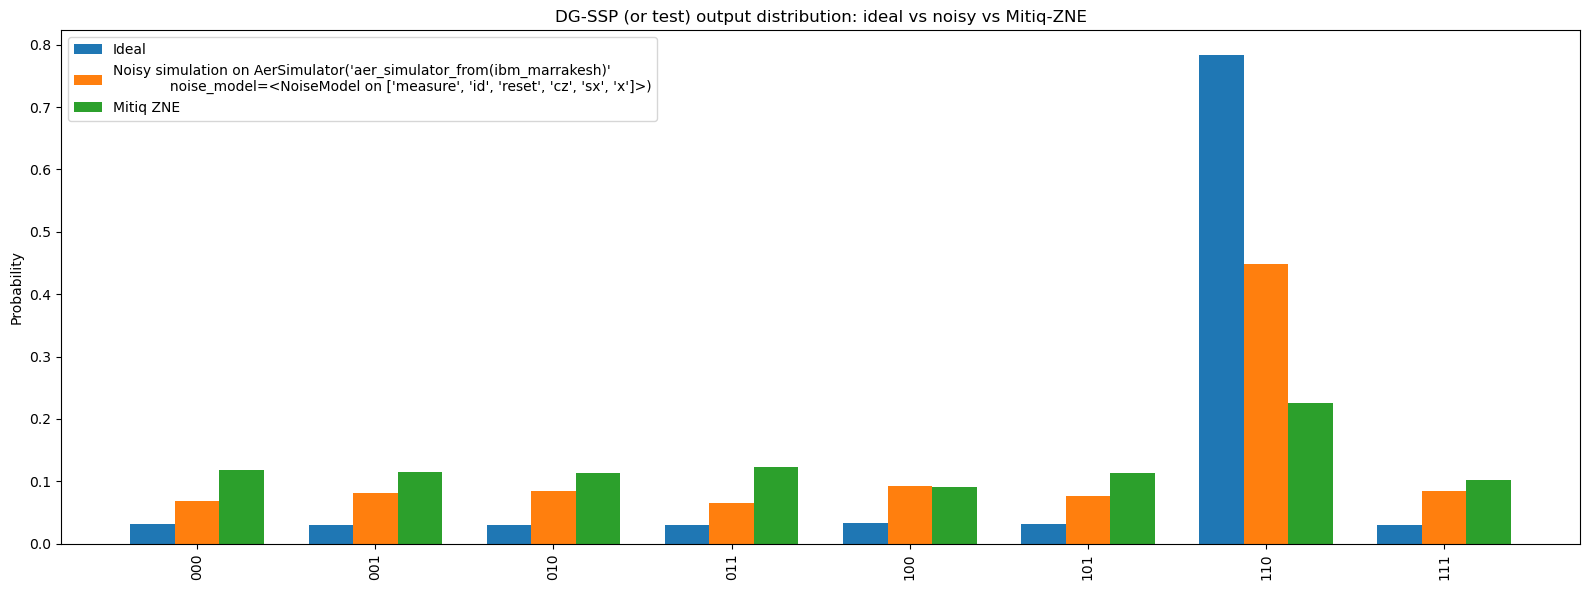

In [19]:
# Ideal distribution (noiseless Aer)
ideal_backend = AerSimulator()  # default is (approximately) noiseless
ideal_counts = run_qiskit_circuit(qc, backend=ideal_backend, shots=20_000)
p_ideal = {b: c / 20_000 for b, c in ideal_counts.items()}

# Noisy distribution (Fake Torino noise)
noisy_counts = run_qiskit_circuit(qc, backend=noisy_backend, shots=20_000)
p_noisy = {b: c / 20_000 for b, c in noisy_counts.items()}

# Mitiq-ZNE mitigated distribution
p_mitiq = mitiq_zne_mitigated_distribution(
    qc,
    backend=fake_backends[2],
    scale_factors=(1,3,5,7),
    shots_baseline=5000,
    shots_per_point=5000,
)

# --- Plot ---
all_bits = sorted(set(p_ideal) | set(p_noisy) | set(p_mitiq))

def vec(dist, keys):
    return [dist.get(k, 0.0) for k in keys]

x = np.arange(len(all_bits))

plt.figure(figsize=(16, 6))
w = 0.25
plt.bar(x - w, vec(p_ideal, all_bits), width=w, label="Ideal")
plt.bar(x,     vec(p_noisy, all_bits), width=w, label=noisy_label)
plt.bar(x + w, vec(p_mitiq, all_bits), width=w, label="Mitiq ZNE")

plt.xticks(x, all_bits, rotation=90)
plt.ylabel("Probability")
plt.title("DG-SSP (or test) output distribution: ideal vs noisy vs Mitiq-ZNE")
plt.legend()
plt.tight_layout()
plt.show()
